In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
X = np.arange(100).reshape(-1, 1)
y = np.random.normal(65, 3, 100)
y[55] = 92

x is time, y is temprature

In [3]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4]:
print(model.coef_)
print(model.intercept_)

[-0.00657854]
65.76758482480614


y=kx+b coef:k  intercept:b

In [5]:
y_pred = model.predict(X)

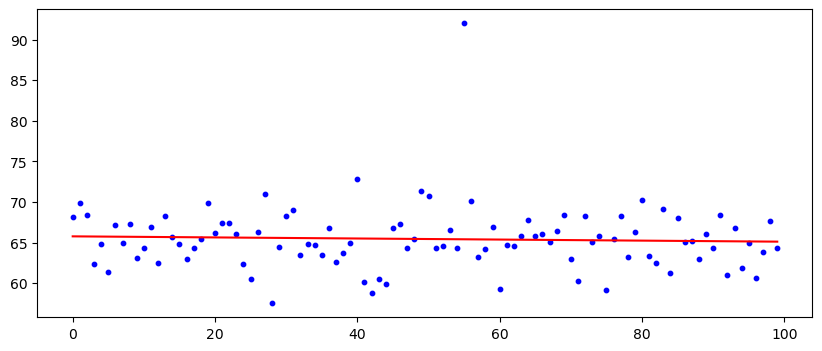

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
axes.scatter(X, y, color="blue", s=10)
axes.plot(X, y_pred, color="red")
plt.show()

In [7]:
y = y + X.flatten() * 0.1

This means that the temperature rises by 0.1 degrees for every unit of time that passes.

In [8]:
print(model.coef_)
print(model.intercept_)

[-0.00657854]
65.76758482480614


In [9]:
from sklearn.metrics import r2_score
print(r2_score(y, y_pred))

-1.1010950956898968


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

test_size=0.2 = 20% of the data is used for testing, and 80% for training.
random_state=42 = Fixed random seed; 42 is commonly used in machine learning.

In [11]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred_test = model2.predict(X_test)
print(r2_score(y_test, y_pred_test))

0.5815717349563969


In [12]:
print(55 in X_test)

False


In [13]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(r2_score(y_test, y_pred_rf))

0.27734979079433875


In [14]:
print("Linear Regression R²:", r2_score(y_test, y_pred_test))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Linear Regression R²: 0.5815717349563969
Random Forest R²: 0.27734979079433875


In [15]:
import pandas as pd
np.random.seed(42)
df2 = pd.DataFrame({
    "pressure": np.random.normal(100, 5, 100),
    "temp": np.random.normal(65, 3, 100),
    "vibration": np.random.normal(0.5, 0.1, 100)
})
df2.loc[30, "pressure"] = 145
df2.loc[55, "temp"] = 92
df2.loc[78, "vibration"] = 1.8

y2 = df2["temp"] + np.random.normal(0, 1, 100)

In [16]:
X2 = df2[["pressure", "temp", "vibration"]]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf2.fit(X2_train, y2_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
importances = model_rf2.feature_importances_
for name, importance in zip(X2.columns, importances):
    print(f"{name}: {importance:.3f}")

pressure: 0.027
temp: 0.959
vibration: 0.014


zip: let the name and its own importances be matched
loop through each pair of (feature name, importance value)

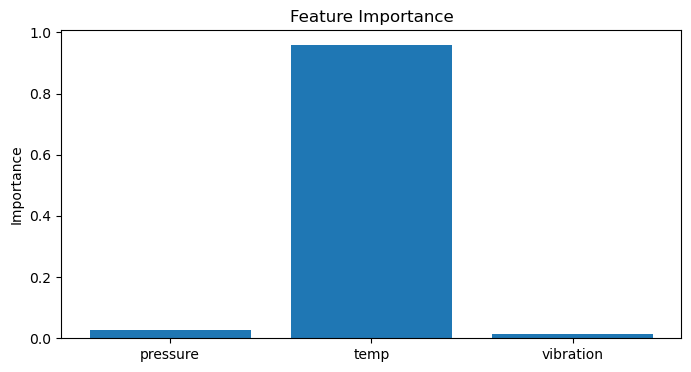

In [18]:
plt.figure(figsize=(8, 4))
plt.bar(X2.columns, importances)
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model_rf2,X2,y2,cv=5)
print(scores)
print(scores.mean())

[0.91758329 0.86087592 0.50923731 0.86763703 0.72035843]
0.7751383958877577


## Cross Validation
Using 5-fold cross validation to evaluate model performance more reliably than a single train/test split.

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X2_scaled = scaler.fit_transform(X2)
print(X2_scaled[:3])
print(X2[:3])

[[ 0.39475041 -1.18010059  0.09740965]
 [-0.10205106 -0.41527023  0.21828493]
 [ 0.51287142 -0.35535033  0.52927025]]
     pressure       temp  vibration
0  102.483571  60.753888   0.535779
1   99.308678  63.738064   0.556078
2  103.238443  63.971856   0.608305


In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X2_scaled=scaler.fit_transform(X2)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)
model_rf3 = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf3.fit(X_train, y_train)
y_pred_rf3 = model_rf3.predict(X_test)
from sklearn.metrics import r2_score
print(r2_score(y2_test,y_pred_rf3))

0.9233227464286694


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best R2 score:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best R2 score: 0.7620825423445485


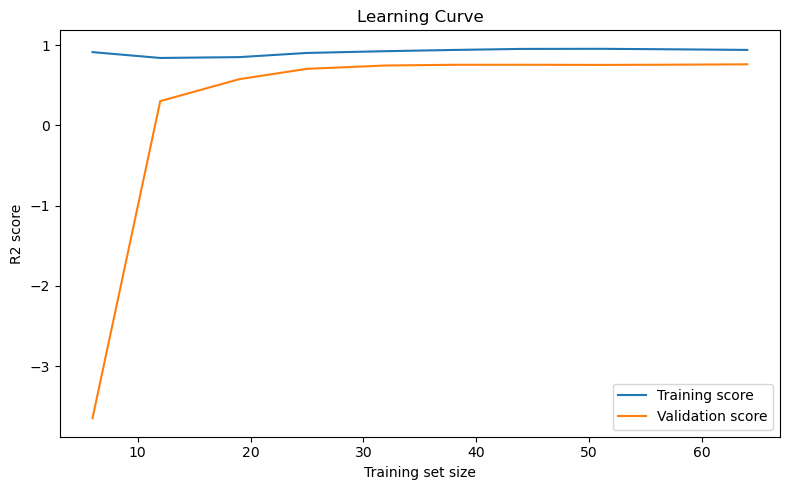

In [23]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, random_state=42),
    X_train, y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation score')
plt.xlabel('Training set size')
plt.ylabel('R2 score')
plt.title('Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

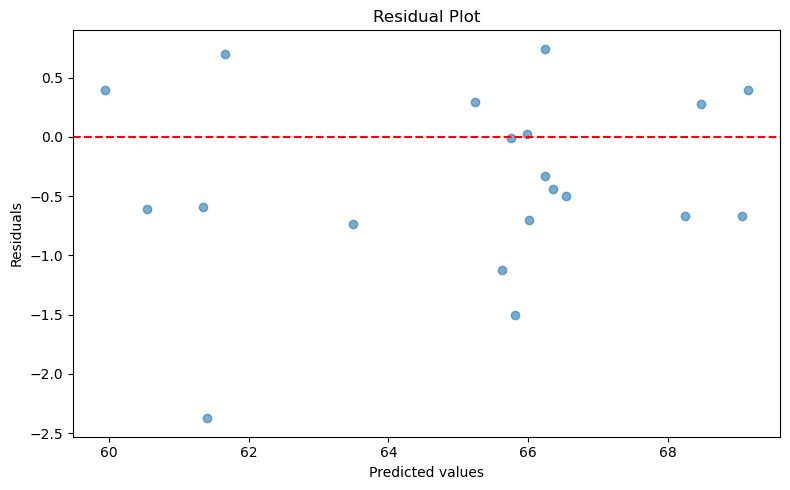

In [24]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.pipeline import Pipeline

In [27]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [28]:
y_pred_pipe = pipeline.predict(X_test)
print(r2_score(y_test, y_pred_pipe))

0.9233227464286694
